# Linear & Logistic Regression — Hands-On Notebook

This notebook is the practical companion to the slide deck. Every code cell has a comment on (almost) every line explaining exactly what that line does — so you can run it live with students, pause on any line, and explain it in plain English.

**We use one running example throughout:**
- `hours` = how many hours a student studied
- First we predict their exact exam `score` (**Linear Regression**)
- Then we flip it into a yes/no question: did they `pass`? (**Logistic Regression**)

Run each cell top to bottom with **Shift + Enter**. Feel free to change numbers and re-run cells to see what happens — that's the best way to build intuition.

## Setup — Import the Libraries We'll Use

In [2]:
# pandas: lets us store and work with data in table form, like a spreadsheet
import pandas as pd

# numpy: gives us tools for numerical operations, like generating ranges of numbers
import numpy as np

# matplotlib: the library we'll use to draw charts and graphs
import matplotlib.pyplot as plt

# train_test_split: splits our data into a "training" part and a "testing" part
from sklearn.model_selection import train_test_split

# LinearRegression: the model we'll use in Part 1, to predict a NUMBER
from sklearn.linear_model import LinearRegression

# LogisticRegression: the model we'll use in Part 2, to predict a YES/NO category
from sklearn.linear_model import LogisticRegression

# these are the scoring tools we'll use to check how good our models are
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix

print("All libraries loaded successfully!")  # if this prints with no errors above, we're ready to go

All libraries loaded successfully!


# Part 1 — Linear Regression

**Goal:** predict a student's exam `score` from how many `hours` they studied.

## Step 1 — Create the Data

In [3]:
# We're typing the dataset in by hand so it's easy to follow along.
# In a real project this would usually be loaded from a CSV file instead.
data = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5, 6, 7, 8, 9],           # how many hours each student studied
    "score": [35, 40, 50, 55, 65, 70, 78, 85, 92]   # the exam score that student got
})

data  # just typing a variable name on its own line displays it as a table in Jupyter/Colab

,hours,score
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65
5,6,70
6,7,78
7,8,85
8,9,92


## Step 2 — Look at the Data First

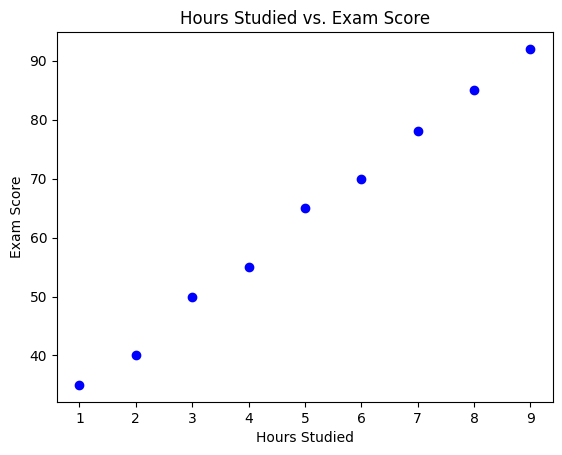

In [4]:
# Always look at your data before modeling it.
# A scatter plot shows each student as one dot: x = hours studied, y = exam score.
plt.scatter(data["hours"], data["score"], color="blue")

plt.xlabel("Hours Studied")      # label for the horizontal axis
plt.ylabel("Exam Score")         # label for the vertical axis
plt.title("Hours Studied vs. Exam Score")   # a title so the chart is self-explanatory

plt.show()   # actually renders the chart below this cell

Notice the dots roughly follow a straight line — as hours go up, score goes up too. That's exactly the kind of pattern Linear Regression is built to find.

## Step 3 — Prepare X (input) and y (target)

In [5]:
# X must always be 2D (a table of feature columns) — that's why we use DOUBLE brackets,
# even though we only have one feature ("hours") right now.
X = data[["hours"]]

# y is 1D — it's the single column we are trying to predict.
y = data["score"]

print("Shape of X:", X.shape)   # (9, 1)  ->  9 rows, 1 feature column
print("Shape of y:", y.shape)   # (9,)    ->  9 target values

Shape of X: (9, 1)
Shape of y: (9,)


## Step 4 — Split into Training and Test Sets

In [6]:
# We hold back 20% of the data as a "test set" that the model will NEVER see while learning.
# That way, later, we can honestly check how well it predicts data it has never encountered.
# random_state=42 just makes the split reproducible -- we'll get the same split every time we run this cell.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))   # how many students the model will learn from
print("Test rows:", len(X_test))        # how many students we'll use to check its predictions

Training rows: 7
Test rows: 2


## Step 5 — Create and Train the Model

In [7]:
# Create a brand new Linear Regression model. Right now it knows nothing.
model = LinearRegression()

# .fit() is where the actual "learning" happens: the model works out the slope (w)
# and intercept (b) that make its predictions as close as possible to y_train.
model.fit(X_train, y_train)

# model.coef_ holds the slope(s) the model learned -- coef_[0] is the slope for "hours"
print("Slope (w):", model.coef_[0])

# model.intercept_ holds the intercept (b) -- the predicted score at 0 hours studied
print("Intercept (b):", model.intercept_)

Slope (w): 7.119047619047615
Intercept (b): 27.976190476190496


## Step 6 — Make Predictions

In [8]:
# Ask the trained model to predict scores for the test set -- data it has never seen before.
predictions = model.predict(X_test)

# Build a small table so we can compare the real scores to the model's guesses, side by side.
comparison = pd.DataFrame({
    "hours": X_test["hours"].values,     # the input hours from the test set
    "actual_score": y_test.values,       # what the student actually scored
    "predicted_score": predictions       # what the model predicted
})


comparison   # display the comparison table

,hours,actual_score,predicted_score
0,8,85,84.928571
1,2,40,42.214286


## Step 7 — Evaluate the Model

In [9]:
# R-squared (R2): what share of the pattern in the data our line explains.
# 1.0 = perfect fit. 0 = no better than just guessing the average score every time.
r2 = r2_score(y_test, predictions)

# Mean Squared Error (MSE): the average of (actual - predicted) squared, across all test points.
# Smaller is better -- it means predictions are closer to the real scores.
mse = mean_squared_error(y_test, predictions)
#R² tells us how much of the variation in the target variable is explained by the model.
#Instead of measuring the prediction error directly, it measures how well the model fits the data.

print("R-squared:", round(r2, 3))
print("Mean Squared Error:", round(mse, 2))

R-squared: 0.995
Mean Squared Error: 2.45


## Step 8 — Visualize the Fit Line

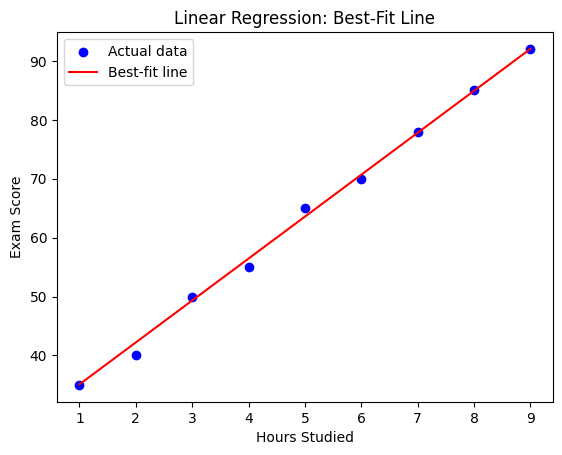

In [10]:
# Plot every real data point as a blue dot (using the FULL dataset, not just the test set).
plt.scatter(X, y, color="blue", label="Actual data")

# Plot the model's predicted line across every hour value in our dataset, in red.
plt.plot(X, model.predict(X), color="red", label="Best-fit line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression: Best-Fit Line")
plt.legend()   # shows the little box explaining what blue dots and the red line mean

plt.show()

## Step 9 — Predict a Brand-New Value

In [11]:
# Let's predict the score for a student who studied 6.5 hours -- a value NOT in our original data.
# It must be wrapped in a DataFrame with the SAME column name ("hours") the model was trained on.
new_hours = pd.DataFrame({"hours": [6.5]})

predicted_score = model.predict(new_hours)   # returns an array, e.g. [72.3]

print(f"Predicted score for 6.5 hours studied: {predicted_score[0]:.1f}")

Predicted score for 6.5 hours studied: 74.2


### Bonus (optional) — Multiple Linear Regression

What if we had a second feature, like the number of practice tests a student took? Let's see how little the code changes.

In [12]:
# Copy the original data so we don't accidentally modify it.
data2 = data.copy()

# Add a made-up second feature: how many practice tests each student took.
data2["practice_tests"] = [0, 1, 1, 2, 2, 3, 3, 4, 4]

# Now X has TWO columns instead of one -- everything else about the workflow stays identical.
X2 = data2[["hours", "practice_tests"]]
y2 = data2["score"]

model2 = LinearRegression()   # a brand new, separate model
model2.fit(X2, y2)            # train on both features at once -- no extra code needed!

print("Weights [hours, practice_tests]:", model2.coef_)
print("Intercept:", model2.intercept_)

Weights [hours, practice_tests]: [ 8.73333333 -3.        ]
Intercept: 26.33333333333333


# Part 2 — Logistic Regression

**Goal:** predict a yes/no answer -- did the student `pass`? -- from how many `hours` they studied.

## Step 1 — Create the Data

In [13]:
# Same idea as before, but now the outcome is a category, not a number:
# 0 = failed, 1 = passed.
data_c = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "passed": [0, 0, 0, 0, 1, 1, 1, 1, 1]   # 0 = fail, 1 = pass
})

data_c   # display the table

,hours,passed
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1


## Step 2 — Look at the Data First

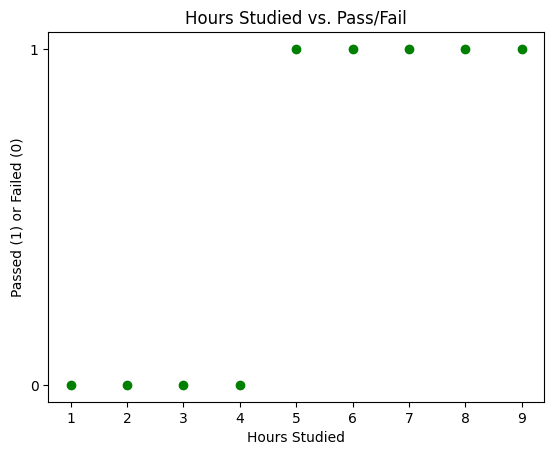

In [14]:
# Plot each student: x = hours studied, y = passed (1) or failed (0).
plt.scatter(data_c["hours"], data_c["passed"], color="green")

plt.xlabel("Hours Studied")
plt.ylabel("Passed (1) or Failed (0)")
plt.title("Hours Studied vs. Pass/Fail")

plt.yticks([0, 1])   # force the y-axis to only show 0 and 1, since those are the only real values

plt.show()

There's no straight line that sensibly fits 0/1 data like this -- a line would predict values below 0 or above 1, which make no sense as a yes/no answer. That's exactly why Logistic Regression exists: it fits an S-shaped curve instead, which we'll see in Step 8.

## Step 3 — Prepare X and y

In [15]:
X_c = data_c[["hours"]]   # features: hours studied (2D, same rule as before)
y_c = data_c["passed"]    # target: 0 or 1

print("Shape of X_c:", X_c.shape)
print("Shape of y_c:", y_c.shape)

Shape of X_c: (9, 1)
Shape of y_c: (9,)


## Step 4 — Split into Training and Test Sets

In [16]:
# Same reasoning as Part 1: hold back 20% of the data to test on honestly, later.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train_c))
print("Test rows:", len(X_test_c))

Training rows: 7
Test rows: 2


## Step 5 — Create and Train the Model

In [17]:
# Create a brand new Logistic Regression model.
model_c = LogisticRegression()

# .fit() trains the model -- internally it uses Log Loss (not MSE) to judge itself,
# since we're now predicting a probability/category, not a plain number.
model_c.fit(X_train_c, y_train_c)

print("Model trained!")

Model trained!


## Step 6 — Make Predictions: Classes and Probabilities

In [18]:
# .predict() gives the FINAL yes/no answer (0 or 1), after applying the 0.5 threshold internally.
class_predictions = model_c.predict(X_test_c)

# .predict_proba() gives the RAW probabilities behind that answer.
# It returns two columns per row: [probability of class 0, probability of class 1].
probabilities = model_c.predict_proba(X_test_c)

comparison_c = pd.DataFrame({
    "hours": X_test_c["hours"].values,
    "actual": y_test_c.values,
    "predicted_class": class_predictions,
    "probability_of_pass": probabilities[:, 1]   # keep just the "probability of passing" column
})

comparison_c   # display the comparison table

,hours,actual,predicted_class,probability_of_pass
0,8,1,1,0.980267
1,2,0,0,0.063420


## Step 7 — Evaluate: Accuracy & Confusion Matrix

In [19]:
# Accuracy: the percentage of test predictions that were exactly correct.
accuracy = accuracy_score(y_test_c, class_predictions)
print("Accuracy:", accuracy)

# Confusion matrix: a 2x2 table showing exactly WHICH mistakes were made, not just how many.
# By scikit-learn's convention: rows = actual values, columns = predicted values.
cm = confusion_matrix(y_test_c, class_predictions)
print("Confusion Matrix (raw):\n", cm)

Accuracy: 1.0
Confusion Matrix (raw):
 [[1 0]
 [0 1]]


In [20]:
# Wrap the confusion matrix in a labeled table so it's much easier to read and explain.
cm_labeled = pd.DataFrame(
    cm,
    index=["Actual: Fail", "Actual: Pass"],        # row labels
    columns=["Predicted: Fail", "Predicted: Pass"]  # column labels
)

cm_labeled   # display the labeled confusion matrix

,Predicted: Fail,Predicted: Pass
Actual: Fail,1,0
Actual: Pass,0,1


## Step 8 — Visualize the Sigmoid Curve

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


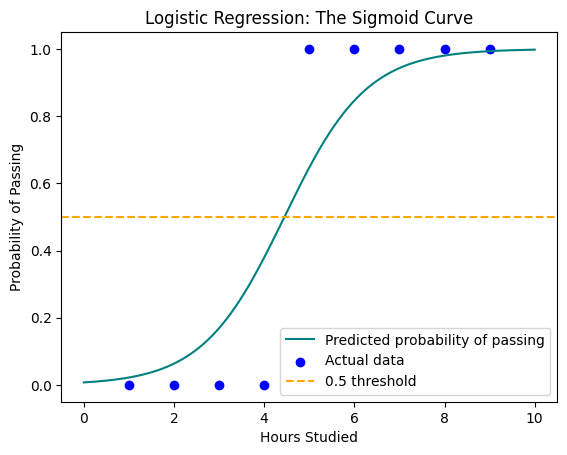

In [21]:
# Generate 200 evenly-spaced hour values from 0 to 10, purely so we can draw a SMOOTH curve.
hours_range = np.linspace(0, 10, 200).reshape(-1, 1)   # reshape makes it 2D, as sklearn expects

# Ask the model for the probability of passing at every one of those 200 hour values.
probs_range = model_c.predict_proba(hours_range)[:, 1]

# Plot the S-shaped probability curve.
plt.plot(hours_range, probs_range, color="teal", label="Predicted probability of passing")

# Plot the real pass/fail data points on top, so we can see how the curve fits them.
plt.scatter(data_c["hours"], data_c["passed"], color="blue", label="Actual data")

# Draw a dashed horizontal line at the 0.5 decision threshold, for reference.
plt.axhline(0.5, color="orange", linestyle="--", label="0.5 threshold")

plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression: The Sigmoid Curve")
plt.legend()

plt.show()

## Step 9 — Predict a Brand-New Value

In [22]:
# Let's check a student who studied 4.5 hours -- right around our decision boundary.
new_student = pd.DataFrame({"hours": [4.5]})

predicted_class = model_c.predict(new_student)         # the final 0/1 answer
predicted_prob = model_c.predict_proba(new_student)     # the underlying probabilities

print("Predicted class (0 = fail, 1 = pass):", predicted_class[0])
print(f"Probability of passing: {predicted_prob[0][1]:.2f}")

Predicted class (0 = fail, 1 = pass): 1
Probability of passing: 0.51


## Recap

**Linear Regression**
- Predicts a NUMBER by fitting a straight line: `y = wx + b`
- Trained by minimizing Mean Squared Error
- Evaluated with R-squared and MSE

**Logistic Regression**
- Predicts a YES/NO category by fitting an S-shaped (sigmoid) curve
- Trained by minimizing Log Loss
- Evaluated with Accuracy and the Confusion Matrix

**The workflow is nearly identical for both:**
load data → look at it → prepare X and y → split → `.fit()` → `.predict()` → evaluate → visualize.

---

### Try It Yourself (optional)

Add a new code cell below and try:
1. Change the `score` or `passed` values in the data and re-run everything -- how do the slope, R-squared, or accuracy change?
2. Predict the score / pass probability for a student who studied 10 hours, or 0.5 hours.
3. In Part 1's bonus section, add a third feature and see how the model handles it.

In [23]:
# Create a new dataset with a different pattern
data_steeper = pd.DataFrame({
    "hours": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "score": [20, 35, 50, 65, 80, 88, 94, 98, 100]  # steeper slope
})

# Re‑run the linear regression workflow
X_st = data_steeper[["hours"]]
y_st = data_steeper["score"]

X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_st, y_st, test_size=0.2, random_state=42
)

model_st = LinearRegression()
model_st.fit(X_train_st, y_train_st)
pred_st = model_st.predict(X_test_st)

print("New slope:", model_st.coef_[0])
print("New intercept:", model_st.intercept_)
print("New R²:", r2_score(y_test_st, pred_st))

New slope: 10.26190476190476
New intercept: 19.690476190476204
New R²: 0.9790776476879489


In [26]:
# Predict for 10 hours (linear)
new_hours_10 = pd.DataFrame({"hours": [10]})
score_10 = model.predict(new_hours_10)
print(f"Linear: 10 hours → score: {score_10[0]:.1f}")

# Predict for 0.5 hours (logistic)
new_hours_half = pd.DataFrame({"hours": [0.5]})
prob_half = model_c.predict_proba(new_hours_half)
print(f"Logistic: 0.5 hours → pass probability: {prob_half[0][1]:.2f}")

Linear: 10 hours → score: 99.2
Logistic: 0.5 hours → pass probability: 0.01


In [25]:
# Extend the multiple linear regression example with a 3rd feature: "sleep_hours"
data3 = data.copy()
data3["practice_tests"] = [0, 1, 1, 2, 2, 3, 3, 4, 4]
data3["sleep_hours"]   = [5, 6, 6, 7, 7, 8, 8, 9, 9]   # new feature

X3 = data3[["hours", "practice_tests", "sleep_hours"]]
y3 = data3["score"]

model3 = LinearRegression()
model3.fit(X3, y3)

print("Weights (hours, practice_tests, sleep_hours):", model3.coef_)
print("Intercept:", model3.intercept_)

# Predict for a student: 6 hours, 3 practice tests, 7 hours sleep
new_student3 = pd.DataFrame({
    "hours": [6],
    "practice_tests": [3],
    "sleep_hours": [7]
})
print("Predicted score:", model3.predict(new_student3)[0])

Weights (hours, practice_tests, sleep_hours): [ 8.73333333 -1.5        -1.5       ]
Intercept: 33.8333333333333
Predicted score: 71.23333333333333
